In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab\ Notebooks/fraud-detection

import os
os.makedirs("plots", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

!pip install xgboost lightgbm -q

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/fraud-detection


In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils import compute_class_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
df = pd.read_csv("creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
# For XGBoost
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# For LightGBM
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

weights = dict(zip(np.unique(y_train), class_weights))

In [7]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42
)

lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42
)

In [8]:
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("Training LightGBM...")
lgb_model.fit(X_train, y_train)


Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060569 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

LGBMClassifier(class_weight='balanced', learning_rate=0.05, max_depth=4,
               n_estimators=200, random_state=42)

In [9]:
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_roc = roc_auc_score(y_test, xgb_probs)
xgb_pr = average_precision_score(y_test, xgb_probs)

lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
lgb_roc = roc_auc_score(y_test, lgb_probs)
lgb_pr = average_precision_score(y_test, lgb_probs)

final_df = pd.DataFrame({
    "Model": ["Final_XGBoost", "Final_LightGBM"],
    "ROC_AUC": [xgb_roc, lgb_roc],
    "PR_AUC": [xgb_pr, lgb_pr]
})

print("\nFinal Evaluation Results:")
print(final_df)

final_df.to_csv("results/final_results.csv", index=False)


Final Evaluation Results:
            Model   ROC_AUC    PR_AUC
0   Final_XGBoost  0.982626  0.807872
1  Final_LightGBM  0.979030  0.826876


In [10]:
if xgb_pr >= lgb_pr:
    print("\nXGBoost selected as final production model.")
    best_model = xgb_model
else:
    print("\nLightGBM selected as final production model.")
    best_model = lgb_model

best_model.fit(X, y)

joblib.dump(best_model, "models/final_model.pkl")

print("\nFinal model saved to models/final_model.pkl")


LightGBM selected as final production model.
[LightGBM] [Info] Number of positive: 492, number of negative: 284315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.178477 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 284807, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

In [11]:
!pip install shap -q

In [12]:
import shap
import matplotlib.pyplot as plt

In [13]:

print("\nGenerating SHAP explanations...")

explainer = shap.TreeExplainer(best_model)

X_sample = X_test.sample(1000, random_state=42)

shap_values = explainer.shap_values(X_sample)


Generating SHAP explanations...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


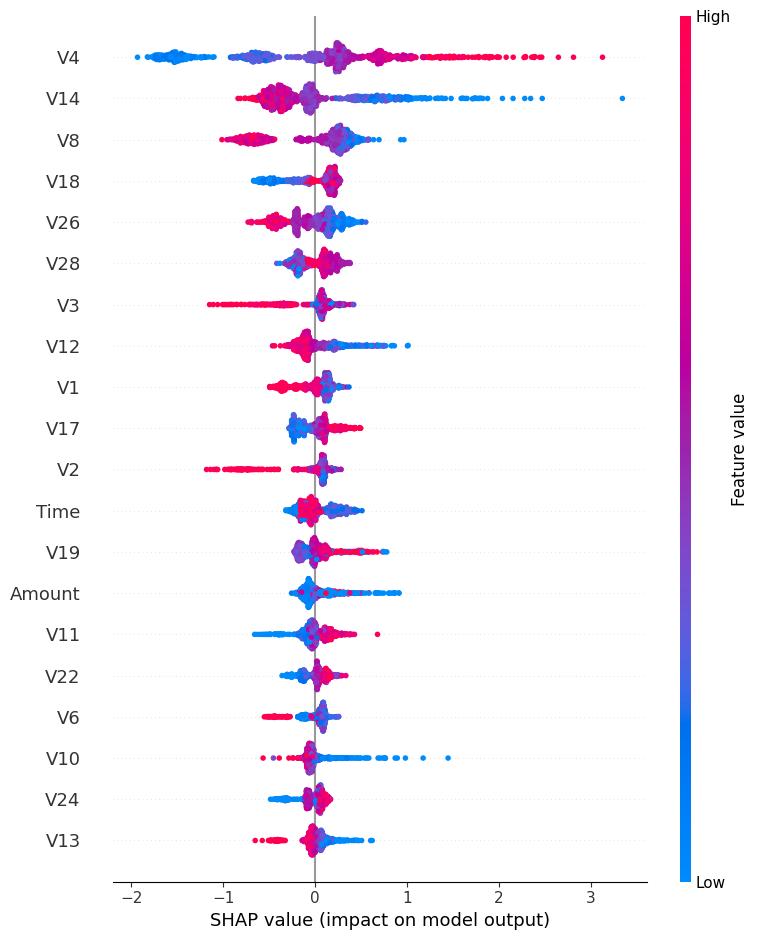

In [14]:
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("plots/shap_summary.png")
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


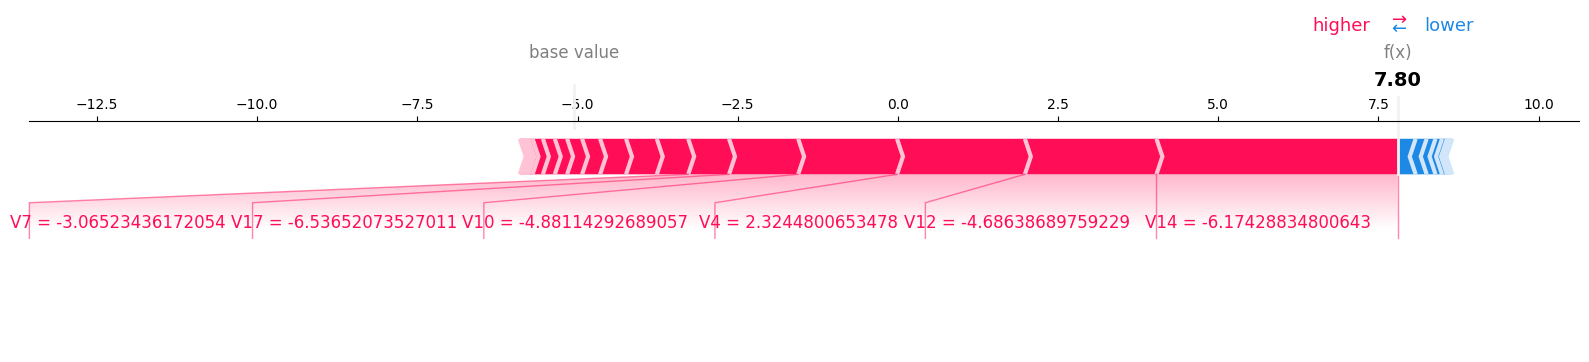

In [15]:
fraud_example = X_test[y_test == 1].iloc[0:1]

shap.force_plot(
    explainer.expected_value,
    explainer.shap_values(fraud_example),
    fraud_example,
    matplotlib=True
)